# Potentially Problematic
Scraping may violate a website's rules if
The site's Terms of Service prohibit automated scraping
 You bypass paywalls, CAPTCHAs, or access controls
You scrape personal/private user information
You collect copyrighted content in bulk and redistribute it
Your scraper causes performance issues for the site

#  Import Libraries

In [6]:
import pandas as pd
import requests
from bs4 import BeautifulSoup

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Web Scraping

In [7]:
HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/114.0.0.0 Safari/537.36"
    ),
    "Accept-Language": "en-US,en;q=0.9",
}

In [8]:
def get_soup(url):
    response = requests.get(url, headers=HEADERS, timeout=15)
    response.raise_for_status()
    return BeautifulSoup(response.text, "html.parser")

# Scrape Race Results

In [9]:
race_url = "https://www.formula1.com/en/results/2025/races"

soup_races = get_soup(race_url)

table = soup_races.find("div", id="results-table")

if table is None:
    table = soup_races.find("table")

rows = []

if table:

    headers = [th.get_text(strip=True) for th in table.find_all("th")]
    print("Columns Found:")
    print(headers)

    for tr in table.find_all("tr")[1:]:

        cells = tr.find_all("td")

        if not cells:
            continue

        gp_link = cells[0].find("a")
        grand_prix = (
            gp_link.get_text(strip=True)
            if gp_link
            else cells[0].get_text(strip=True)
        )

        date = cells[1].get_text(strip=True)

        winner = cells[2].get_text(" ", strip=True)

        team = cells[3].get_text(" ", strip=True)

        laps = cells[4].get_text(strip=True)

        time = cells[5].get_text(strip=True)

        rows.append({
            "Grand Prix": grand_prix,
            "Date": date,
            "Winner": winner,
            "Team": team,
            "Laps": laps,
            "Time": time
        })

print("Total Races Scraped:", len(rows))

Columns Found:
['Grand Prix', 'Date', 'Winner', 'Team', 'Laps', 'Time']
Total Races Scraped: 24


## Create DataFrame

In [10]:
df_races = pd.DataFrame(rows)

df_races.head()

,Grand Prix,Date,Winner,Team,Laps,Time
0,Flag of AustraliaAustralia,16 Mar,Lando Norris NOR,McLaren,57,1:42:06.304
1,Flag of People’s Republic of ChinaChina,23 Mar,Oscar Piastri PIA,McLaren,56,1:30:55.026
2,Flag of JapanJapan,06 Apr,Max Verstappen VER,Red Bull Racing,53,1:22:06.983
3,Flag of BahrainBahrain,13 Apr,Oscar Piastri PIA,McLaren,57,1:35:39.435
4,Flag of Saudi ArabiaSaudi Arabia,20 Apr,Oscar Piastri PIA,McLaren,50,1:21:06.758


In [11]:
# Save Dataset
df_races.to_csv(
    "f1_2025_race_results.csv",
    index=False
)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [12]:
df_races.to_csv("race_schedule.csv", index=False)

print("CSV file created successfully!")

CSV file created successfully!


## DATA UNDERSTANDING

In [13]:
print("Rows, Columns:", df_races.shape)

Rows, Columns: (24, 6)


## Data Types

In [14]:
df_races.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Grand Prix  24 non-null     object
 1   Date        24 non-null     object
 2   Winner      24 non-null     object
 3   Team        24 non-null     object
 4   Laps        24 non-null     object
 5   Time        24 non-null     object
dtypes: object(6)
memory usage: 1.3+ KB


### Statistical Summary

In [15]:
df_races.describe(include="all")

,Grand Prix,Date,Winner,Team,Laps,Time
count,24,24,24,24,24,24
unique,24,24,4,3,15,24
top,Flag of AustraliaAustralia,16 Mar,Max Verstappen VER,McLaren,57,1:42:06.304
freq,1,1,8,14,4,1


### Missing Values

In [16]:
df_races.isnull().sum()

Grand Prix    0
Date          0
Winner        0
Team          0
Laps          0
Time          0
dtype: int64

### Duplicate Records

In [17]:
df_races.duplicated().sum()

np.int64(0)

In [18]:
df_races.drop_duplicates(inplace=True)

### Remove Extra Spaces

In [19]:
df_races["Grand Prix"] = df_races["Grand Prix"].str.strip()
df_races["Winner"] = df_races["Winner"].str.strip()
df_races["Team"] = df_races["Team"].str.strip()

In [20]:
df_races["Laps"] = pd.to_numeric(
    df_races["Laps"],
    errors="coerce"
)

In [21]:
df_races.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Grand Prix  24 non-null     object
 1   Date        24 non-null     object
 2   Winner      24 non-null     object
 3   Team        24 non-null     object
 4   Laps        24 non-null     int64 
 5   Time        24 non-null     object
dtypes: int64(1), object(5)
memory usage: 1.3+ KB


# EXPLORATORY DATA ANALYSIS (EDA)

###  Number of Races

In [22]:



print("Total Races:", len(df_races))

Total Races: 24


## Driver Wins

In [23]:
driver_wins = df_races["Winner"].value_counts()

print(driver_wins)

Winner
Max Verstappen VER    8
Lando Norris NOR      7
Oscar Piastri PIA     7
George Russell RUS    2
Name: count, dtype: int64


## Team Wins

In [24]:
team_wins = df_races["Team"].value_counts()

print(team_wins)

Team
McLaren            14
Red Bull Racing     8
Mercedes            2
Name: count, dtype: int64


### Average Laps

In [25]:
print(
    "Average Laps:",
    round(df_races["Laps"].mean(),2)
)

Average Laps: 60.17


# VISUALIZATION

## Driver Wins

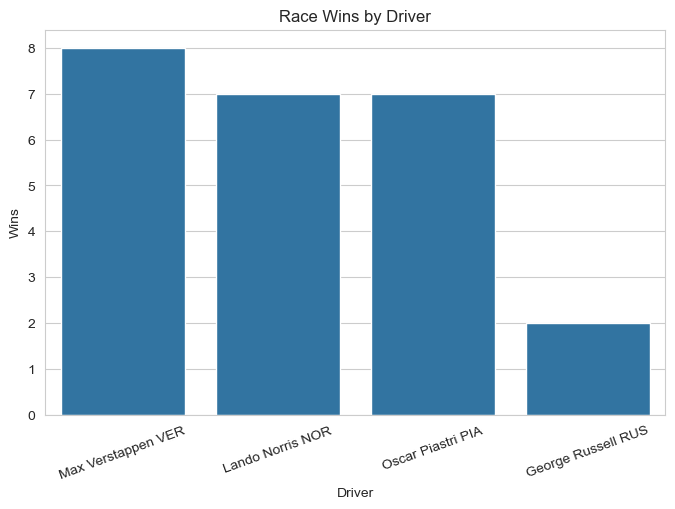

In [26]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_races,
    x="Winner",
    order=df_races["Winner"].value_counts().index
)

plt.title("Race Wins by Driver")
plt.xlabel("Driver")
plt.ylabel("Wins")
plt.xticks(rotation=20)

plt.show()

## Team Wins

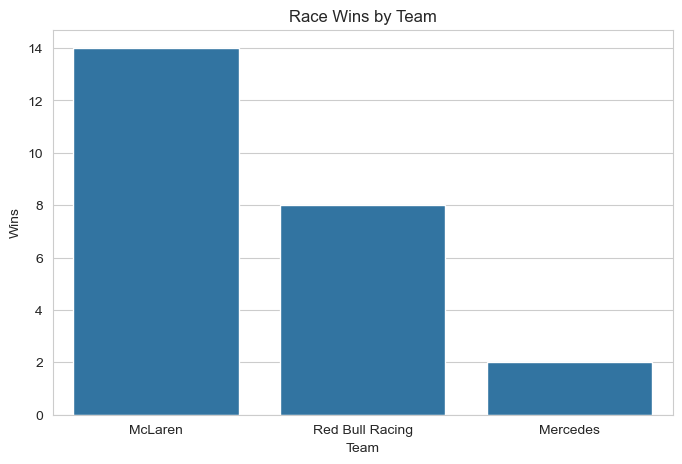

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_races,
    x="Team",
    order=df_races["Team"].value_counts().index
)

plt.title("Race Wins by Team")
plt.xlabel("Team")
plt.ylabel("Wins")

plt.show()

## Laps Distribution

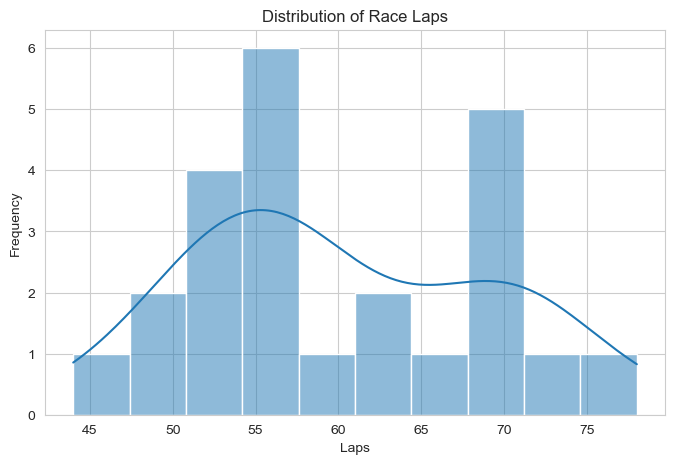

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_races["Laps"],
    bins=10,
    kde=True
)

plt.title("Distribution of Race Laps")
plt.xlabel("Laps")
plt.ylabel("Frequency")

plt.show()


## Top Drivers Bar Plot

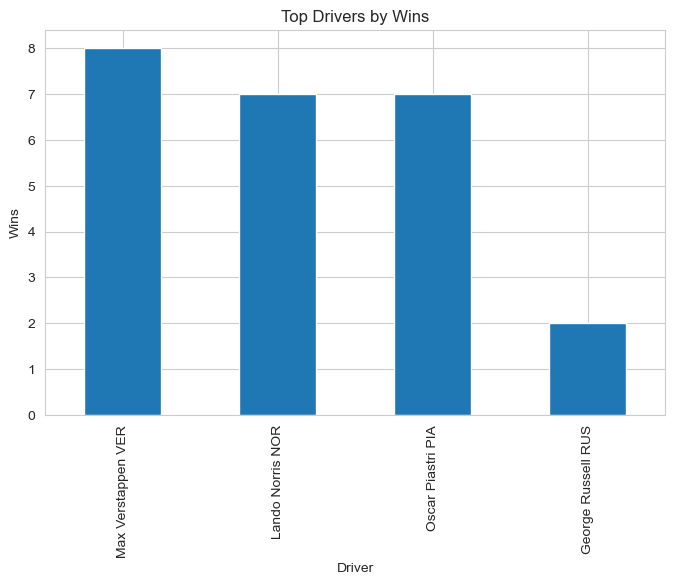

In [29]:
wins = df_races["Winner"].value_counts()

plt.figure(figsize=(8,5))

wins.plot(kind="bar")

plt.title("Top Drivers by Wins")
plt.xlabel("Driver")
plt.ylabel("Wins")

plt.show()

## Team Win Share Pie Chart

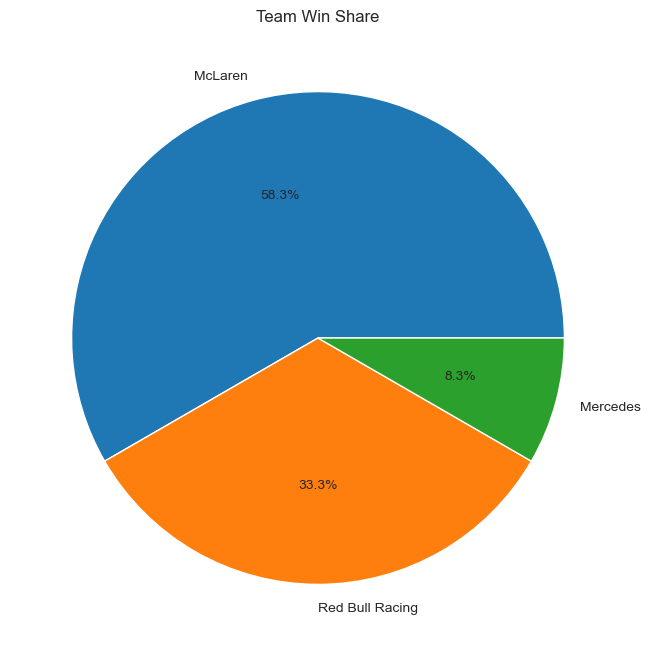

In [30]:
team_wins = df_races["Team"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    team_wins,
    labels=team_wins.index,
    autopct="%1.1f%%"
)

plt.title("Team Win Share")

plt.show()

## Grand Prix vs Laps

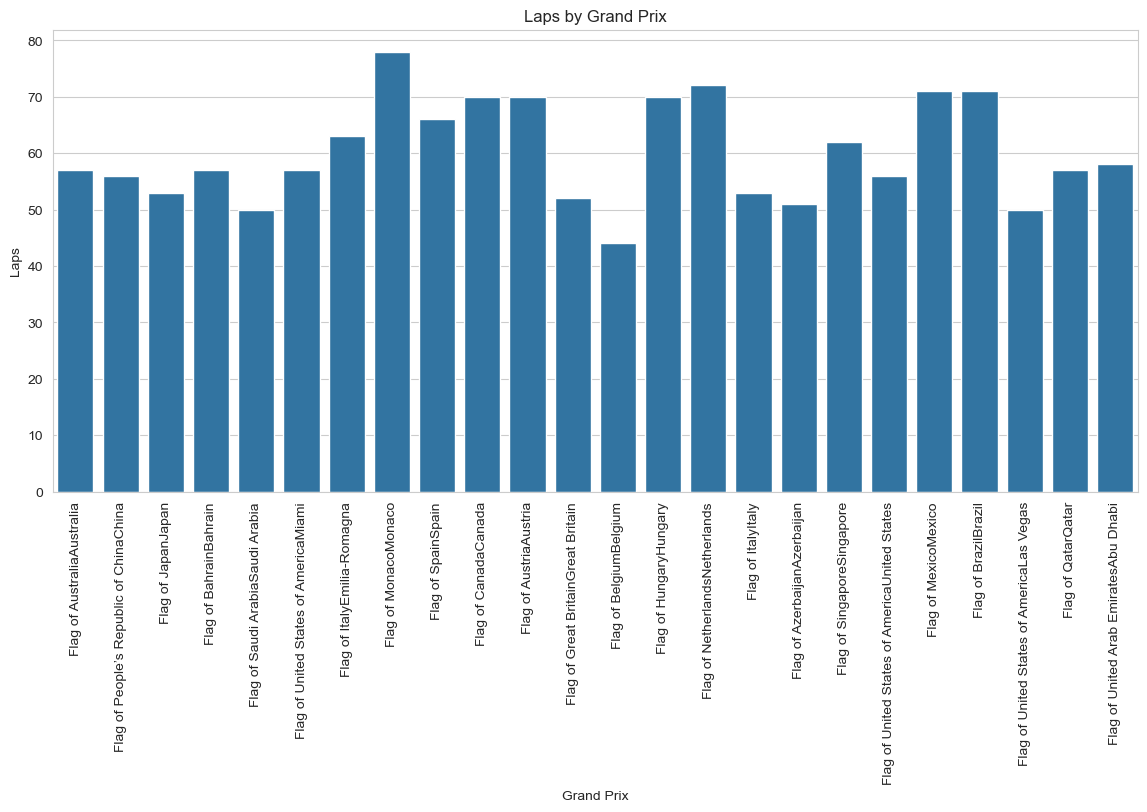

In [31]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=df_races,
    x="Grand Prix",
    y="Laps"
)

plt.xticks(rotation=90)

plt.title("Laps by Grand Prix")

plt.show()

## Heatmap

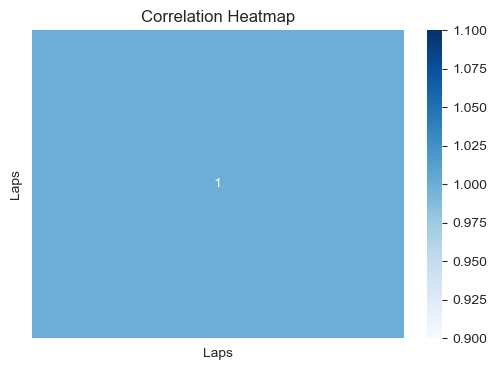

In [32]:



plt.figure(figsize=(6,4))

sns.heatmap(
    df_races[["Laps"]].corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")

plt.show()

## 

In [33]:
print("Top Driver:")
print(df_races["Winner"].value_counts().idxmax())

print("\nTop Team:")
print(df_races["Team"].value_counts().idxmax())

print("\nAverage Laps:")
print(round(df_races["Laps"].mean(),2))

Top Driver:
Max Verstappen VER

Top Team:
McLaren

Average Laps:
60.17




###### 